# Cats vs Dogs Classification
**Model**: EfficientNet-B0 (transfer learning)  
**Techniques**: Data Augmentation + CosineAnnealingLR + Early Stopping

---
### Steps
1. Mount Google Drive & clone repo
2. Install dependencies
3. Download dataset
4. Train
5. Evaluate

## 1. Mount Google Drive

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Clone Repo

In [34]:
import os

REPO_URL = "https://github.com/chungmingwang/cats-vs-dogs.git"
REPO_DIR = "/content/cats-vs-dogs"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

%cd {REPO_DIR}

Updating cc88ca8..1156467
error: Your local changes to the following files would be overwritten by merge:
	config.yaml
Please commit your changes or stash them before you merge.
Aborting
/content/cats-vs-dogs


## 3. Install Dependencies

In [35]:
!pip install -q -r requirements.txt

## 4. Prepare Dataset

In [ ]:
DATA_DIR = "/content/drive/MyDrive/cats-vs-dogs/"
RAW_DIR  = f"{DATA_DIR}/raw"

if not os.path.exists(RAW_DIR):
    print("Unzipping dataset...")
    !unzip -q "{DATA_DIR}/dogs-vs-cats.zip" -d "{DATA_DIR}"
    !unzip -q "{DATA_DIR}/train.zip"        -d "{RAW_DIR}"
    print("Done.")
else:
    print(f"Dataset already exists at {RAW_DIR}")

print(f"Total images: {len(os.listdir(f"{RAW_DIR}/train/"))}")

Dataset already exists at /content/drive/MyDrive/cats-vs-dogs/data/raw/
Total images: 25000


## 5. Verify GPU

In [37]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


## 6. Train

Checkpoint and logs are saved to `/content/drive/MyDrive/cats-vs-dogs/outputs/`.

In [38]:
!python train.py --config config.yaml

Using device: cuda
Train: 22500  Val: 2500
Epoch [001/20] train_loss=0.1887  val_loss=0.6119  val_acc=0.9232
  -> Saved best checkpoint (val_acc=0.9232)
Epoch [002/20] train_loss=0.0938  val_loss=0.0447  val_acc=0.9812
  -> Saved best checkpoint (val_acc=0.9812)
Epoch [003/20] train_loss=0.0493  val_loss=0.0950  val_acc=0.9652
Epoch [004/20] train_loss=0.0434  val_loss=0.0407  val_acc=0.9852
  -> Saved best checkpoint (val_acc=0.9852)
Epoch [005/20] train_loss=0.0430  val_loss=0.0405  val_acc=0.9868
  -> Saved best checkpoint (val_acc=0.9868)
Epoch [006/20] train_loss=0.0403  val_loss=0.0422  val_acc=0.9836
Epoch [007/20] train_loss=0.0326  val_loss=0.0413  val_acc=0.9840
Epoch [008/20] train_loss=0.0346  val_loss=0.0402  val_acc=0.9880
  -> Saved best checkpoint (val_acc=0.9880)
Epoch [009/20] train_loss=0.0262  val_loss=0.0395  val_acc=0.9880
Epoch [010/20] train_loss=0.0227  val_loss=0.0519  val_acc=0.9812
Epoch [011/20] train_loss=0.0169  val_loss=0.0418  val_acc=0.9868
Epoch [012/

## 7. Evaluate

In [39]:
!python evaluate.py --config config.yaml

Using device: cuda
Evaluation set: 2500 images
Loaded checkpoint: /content/drive/MyDrive/cats-vs-dogs/outputs/best.pth  (saved at epoch 8)
Evaluating: 100% 40/40 [00:11<00:00,  3.57it/s]

========== Evaluation Results ==========
  Accuracy  : 0.9880
  Precision : 0.9887
  Recall    : 0.9871
Confusion matrix saved to /content/drive/MyDrive/cats-vs-dogs/outputs/confusion_matrix.png
ROC curve saved to /content/drive/MyDrive/cats-vs-dogs/outputs/roc_curve.png
  AUC-ROC   : 0.9992


## 8. Display Results

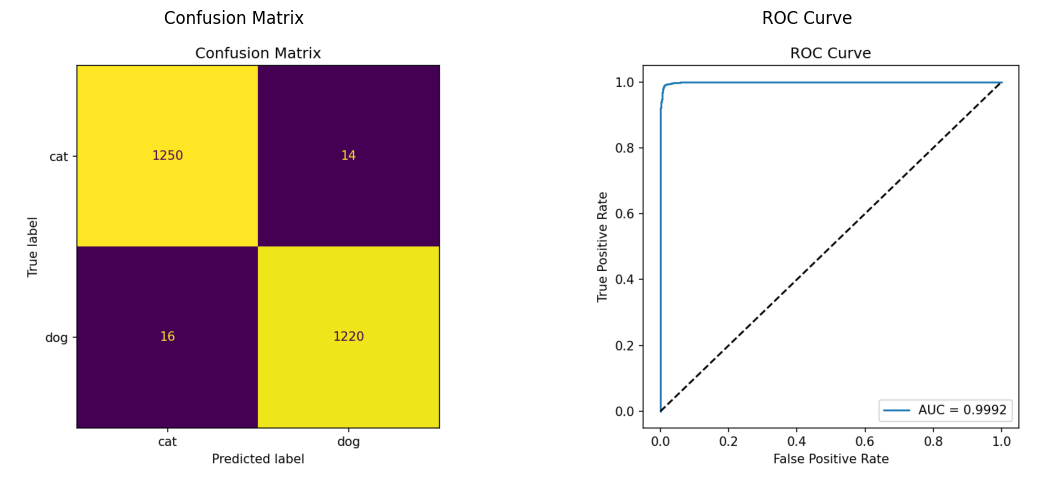

In [40]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import yaml

with open("config.yaml") as f:
    config = yaml.safe_load(f)
output_dir = config["output"]["dir"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, fname, title in zip(
    axes,
    ["confusion_matrix.png", "roc_curve.png"],
    ["Confusion Matrix", "ROC Curve"],
):
    img = mpimg.imread(f"{output_dir}/{fname}")
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()